# Lab 1.2: Byte-Pair Encoding (BPE) Tokenization

**Course:** Advanced Natural Language Processing (NLP702/806)

**Instructor:** Dr. Fajri Koto

---


**Byte-Pair Encoding (BPE)** is a subword tokenization algorithm that was originally developed for data compression but has become widely adopted in Natural Language Processing, especially in neural machine translation and large language models.

### Key Concepts:

1. **Subword Tokenization**: Instead of splitting text into words or characters, BPE creates a vocabulary of subword units
2. **Data-Driven**: The vocabulary is learned from the training data
3. **Flexible**: Can handle out-of-vocabulary words by breaking them into known subwords
4. **Efficient**: Balances between word-level and character-level representations

### Why BPE?

**Problems with traditional tokenization:**
- **Word-level**: Large vocabulary, many OOV (out-of-vocabulary) words
- **Character-level**: Very long sequences, loses semantic meaning

**BPE advantages:**
- ✅ Smaller vocabulary than word-level
- ✅ No OOV problems (can represent any word)
- ✅ Captures frequent subword patterns
- ✅ Shorter sequences than character-level

### How BPE Works (High-level):

1. **Start** with character-level vocabulary
2. **Find** the most frequent pair of consecutive symbols
3. **Merge** this pair into a new symbol
4. **Repeat** until desired vocabulary size is reached
5. **Tokenize** new text using learned merge rules

In [1]:
# Let's start with necessary imports
import urllib
from collections import defaultdict

import matplotlib.pyplot as plt

## Section 1: Byte-Pair Encoding Algorithm

Let's implement BPE from scratch to understand how it works!

In [2]:
class SimpleBPE:
    """
    A simple implementation of Byte-Pair Encoding for educational purposes
    """
    
    def __init__(self):
        self.word_freqs = {}
        self.vocab = set()
        self.merges = {}
        
    def get_word_tokens_from_corpus(self, corpus):
        """
        Step 1: Convert corpus into initial word tokens (character-level + end token)
        """
        word_freqs = defaultdict(int)
        
        # Split corpus into words and count frequencies
        for word in corpus.split():
            word_freqs[word] += 1
            
        # Convert each word to character-level representation
        word_tokens = {}
        for word, freq in word_freqs.items():
            # Add space between characters and append end-of-word token
            tokens = list(word) + ['</w>']
            word_tokens[' '.join(tokens)] = freq
            
        return word_tokens
    
    def get_pairs(self, word_tokens):
        """
        Step 2: Get all pairs of consecutive symbols and their frequencies
        """
        pairs = defaultdict(int)
        
        for word, freq in word_tokens.items():
            symbols = word.split()
            for i in range(len(symbols) - 1):
                pairs[(symbols[i], symbols[i + 1])] += freq
                
        return pairs
    
    def merge_vocab(self, pair, word_tokens):
        """
        Step 3: Merge the most frequent pair in vocabulary
        """
        bigram = ' '.join(pair)
        replacement = ''.join(pair)
        
        new_word_tokens = {}
        for word in word_tokens:
            new_word = word.replace(bigram, replacement)
            new_word_tokens[new_word] = word_tokens[word]
            
        return new_word_tokens
    
    def train(self, corpus, num_merges):
        """
        Train BPE model on corpus with specified number of merge operations
        """
        print(f"🚀 Training BPE with {num_merges} merges...")
        #print(f"📝 Original corpus: {repr(corpus)}")
        #print()
        
        # Step 1: Initialize with character-level tokens
        self.word_freqs = self.get_word_tokens_from_corpus(corpus)
        
        print("📊 Initial word frequencies (character-level):")
        for word, freq in sorted(self.word_freqs.items(), key=lambda x: x[1], reverse=True):
            print(f"  '{word}': {freq}")
        print()
        
        # Step 2: Learn merges
        self.merges = {}
        for i in range(num_merges):
            pairs = self.get_pairs(self.word_freqs)
            if not pairs:
                break
                
            # Find most frequent pair
            best_pair = max(pairs, key=pairs.get)
            
            print(f"🔄 Merge {i+1}: Merging {best_pair} (frequency: {pairs[best_pair]})")
            
            # Merge the pair
            self.word_freqs = self.merge_vocab(best_pair, self.word_freqs)
            self.merges[best_pair] = ''.join(best_pair)
            
            print(f"   Result: {best_pair[0]} + {best_pair[1]} → {''.join(best_pair)}")
            print()
            
        # Create final vocabulary
        self.vocab = set()
        for word in self.word_freqs:
            self.vocab.update(word.split())
            
        print("✅ Training completed!")
        print(f"📚 Final vocabulary size: {len(self.vocab)}")
        print(f"🔧 Number of merge rules: {len(self.merges)}")
        
        return self.merges, self.vocab

Let's test our BPE implementation with a fun example inspired by the viral [Pen Pineapple Apple Pen (PPAP)](https://www.youtube.com/watch?v=Ct6BUPvE2sM) song! 

This corpus is perfect for demonstrating BPE because:
- **"apple"** appears both as a standalone word AND within "pineapple"
- **"pen"** appears frequently throughout
- BPE will naturally discover these shared substrings!

In [3]:
bpe = SimpleBPE()

corpus = "i have a pen i have a apple apple pen i have a pen i have pineapple pineapple pen apple pen pineapple pen pen pineapple apple pen pen pineapple apple pen"

# Train the BPE model with 10 merges
merges, vocab = bpe.train(corpus, num_merges=11)

🚀 Training BPE with 11 merges...
📊 Initial word frequencies (character-level):
  'p e n </w>': 10
  'a p p l e </w>': 5
  'p i n e a p p l e </w>': 5
  'i </w>': 4
  'h a v e </w>': 4
  'a </w>': 3

🔄 Merge 1: Merging ('e', '</w>') (frequency: 14)
   Result: e + </w> → e</w>

🔄 Merge 2: Merging ('p', 'e') (frequency: 10)
   Result: p + e → pe

🔄 Merge 3: Merging ('pe', 'n') (frequency: 10)
   Result: pe + n → pen

🔄 Merge 4: Merging ('pen', '</w>') (frequency: 10)
   Result: pen + </w> → pen</w>

🔄 Merge 5: Merging ('a', 'p') (frequency: 10)
   Result: a + p → ap

🔄 Merge 6: Merging ('ap', 'p') (frequency: 10)
   Result: ap + p → app

🔄 Merge 7: Merging ('app', 'l') (frequency: 10)
   Result: app + l → appl

🔄 Merge 8: Merging ('appl', 'e</w>') (frequency: 10)
   Result: appl + e</w> → apple</w>

🔄 Merge 9: Merging ('p', 'i') (frequency: 5)
   Result: p + i → pi

🔄 Merge 10: Merging ('pi', 'n') (frequency: 5)
   Result: pi + n → pin

🔄 Merge 11: Merging ('pin', 'e') (frequency: 5)
   R

In [4]:
print("📋 Final Merge Rules:")
for i, (pair, merged) in enumerate(merges.items(), 1):
    print(f"  {i}. {pair[0]} + {pair[1]} → {merged}")
print()

print(f"📚 Final Vocabulary ({len(vocab)} tokens):")
vocab_list = sorted(list(vocab))
for i, token in enumerate(vocab_list):
    if i % 8 == 0:  # New line every 8 tokens
        print("  ", end="")
    print(f"'{token}'", end=", " if i < len(vocab_list) - 1 else "")
print("\n")

print("🏁 Final word representations:")
for word, freq in sorted(bpe.word_freqs.items(), key=lambda x: x[1], reverse=True):
    print(f"  '{word}' (frequency: {freq})")

📋 Final Merge Rules:
  1. e + </w> → e</w>
  2. p + e → pe
  3. pe + n → pen
  4. pen + </w> → pen</w>
  5. a + p → ap
  6. ap + p → app
  7. app + l → appl
  8. appl + e</w> → apple</w>
  9. p + i → pi
  10. pi + n → pin
  11. pin + e → pine

📚 Final Vocabulary (9 tokens):
  '</w>', 'a', 'apple</w>', 'e</w>', 'h', 'i', 'pen</w>', 'pine',   'v'

🏁 Final word representations:
  'pen</w>' (frequency: 10)
  'apple</w>' (frequency: 5)
  'pine apple</w>' (frequency: 5)
  'i </w>' (frequency: 4)
  'h a v e</w>' (frequency: 4)
  'a </w>' (frequency: 3)


BPE successfully discovered meaningful subword units from our corpus! Let's break down what we learned:

**1. The Merge Process:**
- **Merges 1-4**: BPE discovered "pen" by progressively merging `p + e → pe`, then `pe + n → pen`
- **Merges 5-8**: BPE discovered "apple" by building up from `a + p → ap → app → appl → apple`
- **Merges 9-11**: Started discovering "pine"

**2. Why This Matters:**
- 🎯 **"apple"** was learned as a complete subword unit (`apple</w>`)
- 🎯 **"pen"** was learned as a complete subword unit (`pen</w>`)
- 🎯 **"pineapple"** is represented as `pine apple</w>` - BPE reuses the "apple" token it already learned!

This demonstrates BPE's power: instead of treating "pineapple" as a completely new word requiring a new vocabulary entry, BPE breaks it into parts where one part (`apple</w>`) is already known. This is how BPE handles new or rare words efficiently!

## Section 2: BPE Tokenization - Using the Trained Model

Now that we have our Byte-Pair Encoding (BPE) model trained, let's see how to use it to tokenize new text!

In [5]:
class BPETokenizer(SimpleBPE):
    """
    Extended BPE class with tokenization capabilities
    """
    
    def encode_word(self, word):
        """
        Apply learned merge rules to encode a single word
        """
        # Start with character-level representation
        tokens = list(word) + ['</w>']
        
        # Apply merge rules in order they were learned
        for pair, merged in self.merges.items():
            i = 0
            while i < len(tokens) - 1:
                if tokens[i] == pair[0] and tokens[i + 1] == pair[1]:
                    # Merge the pair
                    tokens = tokens[:i] + [merged] + tokens[i + 2:]
                else:
                    i += 1
                    
        return tokens
    
    def tokenize(self, text):
        """
        Tokenize input text using learned BPE model
        """
        words = text.split()
        all_tokens = []
        
        for word in words:
            tokens = self.encode_word(word)
            all_tokens.extend(tokens)
            
        return all_tokens
    
    def demonstrate_tokenization(self, text):
        """
        Show detailed tokenization process
        """
        print(f"🔤 Tokenizing: '{text}'")
        print("-" * 40)
        
        words = text.split()
        for word in words:
            print(f"\n📝 Word: '{word}'")
            
            # Show step-by-step encoding
            tokens = list(word) + ['</w>']
            print(f"  1️⃣  Initial (character-level): {tokens}")
            
            step = 2
            for pair, merged in self.merges.items():
                old_tokens = tokens.copy()
                i = 0
                while i < len(tokens) - 1:
                    if tokens[i] == pair[0] and tokens[i + 1] == pair[1]:
                        tokens = tokens[:i] + [merged] + tokens[i + 2:]
                    else:
                        i += 1
                
                # Only show if there was a change
                if tokens != old_tokens:
                    print(f"  {step}️⃣  After merging {pair}: {tokens}")
                    step += 1
            
            final_tokens = self.encode_word(word)
            print(f"  ✅ Final tokens: {final_tokens}")
        
        # Show complete tokenization
        all_tokens = self.tokenize(text)
        print(f"\n🎯 Complete tokenization of '{text}': {all_tokens}")
        return all_tokens

In [6]:
# Create tokenizer using our trained model
tokenizer = BPETokenizer()
tokenizer.merges = merges
tokenizer.vocab = vocab
tokenizer.word_freqs = bpe.word_freqs

In [7]:
# Example 1: Words from training corpus
test_words = ["pineapple"]
for word in test_words:
    tokens = tokenizer.demonstrate_tokenization(word)
    print("\n" + "─" * 50)

🔤 Tokenizing: 'pineapple'
----------------------------------------

📝 Word: 'pineapple'
  1️⃣  Initial (character-level): ['p', 'i', 'n', 'e', 'a', 'p', 'p', 'l', 'e', '</w>']
  2️⃣  After merging ('e', '</w>'): ['p', 'i', 'n', 'e', 'a', 'p', 'p', 'l', 'e</w>']
  3️⃣  After merging ('a', 'p'): ['p', 'i', 'n', 'e', 'ap', 'p', 'l', 'e</w>']
  4️⃣  After merging ('ap', 'p'): ['p', 'i', 'n', 'e', 'app', 'l', 'e</w>']
  5️⃣  After merging ('app', 'l'): ['p', 'i', 'n', 'e', 'appl', 'e</w>']
  6️⃣  After merging ('appl', 'e</w>'): ['p', 'i', 'n', 'e', 'apple</w>']
  7️⃣  After merging ('p', 'i'): ['pi', 'n', 'e', 'apple</w>']
  8️⃣  After merging ('pi', 'n'): ['pin', 'e', 'apple</w>']
  9️⃣  After merging ('pin', 'e'): ['pine', 'apple</w>']
  ✅ Final tokens: ['pine', 'apple</w>']

🎯 Complete tokenization of 'pineapple': ['pine', 'apple</w>']

──────────────────────────────────────────────────


In [8]:
# Example 2: New words (not in training corpus)
new_words = ["pinkapple", "party"]
for word in new_words:
    tokens = tokenizer.demonstrate_tokenization(word)
    print("\n" + "─" * 50)

🔤 Tokenizing: 'pinkapple'
----------------------------------------

📝 Word: 'pinkapple'
  1️⃣  Initial (character-level): ['p', 'i', 'n', 'k', 'a', 'p', 'p', 'l', 'e', '</w>']
  2️⃣  After merging ('e', '</w>'): ['p', 'i', 'n', 'k', 'a', 'p', 'p', 'l', 'e</w>']
  3️⃣  After merging ('a', 'p'): ['p', 'i', 'n', 'k', 'ap', 'p', 'l', 'e</w>']
  4️⃣  After merging ('ap', 'p'): ['p', 'i', 'n', 'k', 'app', 'l', 'e</w>']
  5️⃣  After merging ('app', 'l'): ['p', 'i', 'n', 'k', 'appl', 'e</w>']
  6️⃣  After merging ('appl', 'e</w>'): ['p', 'i', 'n', 'k', 'apple</w>']
  7️⃣  After merging ('p', 'i'): ['pi', 'n', 'k', 'apple</w>']
  8️⃣  After merging ('pi', 'n'): ['pin', 'k', 'apple</w>']
  ✅ Final tokens: ['pin', 'k', 'apple</w>']

🎯 Complete tokenization of 'pinkapple': ['pin', 'k', 'apple</w>']

──────────────────────────────────────────────────
🔤 Tokenizing: 'party'
----------------------------------------

📝 Word: 'party'
  1️⃣  Initial (character-level): ['p', 'a', 'r', 't', 'y', '</w>']
  

# Section 3: Comparison with Other Methods

In [9]:
def compare_tokenization_methods(text):
    """
    Compare different tokenization approaches
    """
    words = text.split()
    
    # 1. Word-level tokenization
    word_tokens = words
    print(f"1️⃣  Word-level tokenization:")
    print(f"    Tokens: {word_tokens}")
    print(f"    Count: {len(word_tokens)} tokens")
    print(f"    Vocab size needed: {len(set(word_tokens))} unique words")
    
    # 2. Character-level tokenization  
    char_tokens = list(text.replace(' ', '_'))  # Use _ for spaces
    print(f"\n2️⃣  Character-level tokenization:")
    print(f"    Tokens: {char_tokens}")
    print(f"    Count: {len(char_tokens)} tokens")
    print(f"    Vocab size needed: {len(set(char_tokens))} unique characters")
    
    # 3. BPE tokenization
    bpe_tokens = tokenizer.tokenize(text)
    print(f"\n3️⃣  BPE tokenization:")
    print(f"    Tokens: {bpe_tokens}")
    print(f"    Count: {len(bpe_tokens)} tokens")
    print(f"    Vocab size: {len(tokenizer.vocab)} tokens in vocabulary")
    
    # Calculate compression ratios (using character-level as baseline)
    print(f"\n📊 COMPRESSION ANALYSIS:")
    print(f"    Method          | Tokens | Compression vs Char-level")
    print(f"    ----------------|--------|-------------------------")
    print(f"    Character-level | {len(char_tokens):6} | {len(char_tokens)/len(char_tokens):.2f}x (baseline)")
    print(f"    Word-level      | {len(word_tokens):6} | {len(char_tokens)/len(word_tokens):.2f}x ({(1 - len(word_tokens)/len(char_tokens))*100:.1f}% reduction)")
    print(f"    BPE             | {len(bpe_tokens):6} | {len(char_tokens)/len(bpe_tokens):.2f}x ({(1 - len(bpe_tokens)/len(char_tokens))*100:.1f}% reduction)")
    
    return {
        'word': word_tokens,
        'char': char_tokens, 
        'bpe': bpe_tokens
    }

In [10]:
test_sentence = "pineapple apple pen pinkapple party hello world"
results = compare_tokenization_methods(test_sentence)

1️⃣  Word-level tokenization:
    Tokens: ['pineapple', 'apple', 'pen', 'pinkapple', 'party', 'hello', 'world']
    Count: 7 tokens
    Vocab size needed: 7 unique words

2️⃣  Character-level tokenization:
    Tokens: ['p', 'i', 'n', 'e', 'a', 'p', 'p', 'l', 'e', '_', 'a', 'p', 'p', 'l', 'e', '_', 'p', 'e', 'n', '_', 'p', 'i', 'n', 'k', 'a', 'p', 'p', 'l', 'e', '_', 'p', 'a', 'r', 't', 'y', '_', 'h', 'e', 'l', 'l', 'o', '_', 'w', 'o', 'r', 'l', 'd']
    Count: 47 tokens
    Vocab size needed: 15 unique characters

3️⃣  BPE tokenization:
    Tokens: ['pine', 'apple</w>', 'apple</w>', 'pen</w>', 'pin', 'k', 'apple</w>', 'p', 'a', 'r', 't', 'y', '</w>', 'h', 'e', 'l', 'l', 'o', '</w>', 'w', 'o', 'r', 'l', 'd', '</w>']
    Count: 25 tokens
    Vocab size: 9 tokens in vocabulary

📊 COMPRESSION ANALYSIS:
    Method          | Tokens | Compression vs Char-level
    ----------------|--------|-------------------------
    Character-level |     47 | 1.00x (baseline)
    Word-level      |      7 

The comparison above reveals the fundamental trade-offs between different tokenization methods:

**1. Word-Level Tokenization** (7 tokens, 7 vocab)
- ✅ **Pros**: Shortest sequence, preserves semantic meaning of complete words
- ❌ **Cons**: Vocabulary explodes with rare/new words (e.g., "pinkapple", "hello", "world" all need separate vocab entries)
- ❌ **Fatal flaw**: Cannot handle unseen words without a special `<UNK>` token

**2. Character-Level Tokenization** (47 tokens, 15 vocab)
- ✅ **Pros**: Tiny vocabulary (just 15 unique characters!), can represent ANY word
- ❌ **Cons**: Sequences are 6-7× longer than word-level, loses word boundaries and meaning
- ❌ **Problem**: Neural models must learn to reconstruct word meanings from scratch

**3. BPE Tokenization** (25 tokens, 9 vocab) - *The Sweet Spot!*
- ✅ **Efficient**: 47% reduction from character-level (47 → 25 tokens)
- ✅ **Compact vocab**: Only 9 tokens needed vs 7 for word-level (but handles infinite words!)
- ✅ **Smart reuse**: 
  - `'pineapple'` → `['pine', 'apple</w>']` (reuses learned subwords)
  - `'pinkapple'` → `['pin', 'k', 'apple</w>']` (breaks unknown "pink" but keeps "apple")
  - `'party'` → `['p', 'a', 'r', 't', 'y', '</w>']` (falls back to characters for completely new words)

## Section 4: Real-World Applications and Advanced Concepts

Let's explore how BPE is used in practice and see a more realistic example!

In [11]:
# Fetch the Unicode programming guide for a real-world corpus
url = "https://r.jina.ai/https://www.reedbeta.com/blog/programmers-intro-to-unicode/"

print(f"📥 Fetching content from {url}...")

try:
    with urllib.request.urlopen(url) as response:
        larger_corpus = response.read().decode('utf-8')
    
    print(f"✅ Successfully fetched {len(larger_corpus)} characters")
    print(f"📊 Corpus stats:")
    print(f"   - Total characters: {len(larger_corpus):,}")
    print(f"   - Total words: {len(larger_corpus.split()):,}")
    print(f"   - Unique words: {len(set(larger_corpus.split())):,}")
    
except Exception as e:
    print(f"❌ Error: {e}")

    # Fallback to a smaller corpus
    larger_corpus = """machine learning artificial intelligence deep learning neural networks
natural language processing computer vision data science algorithms
programming python javascript tensorflow pytorch models training
tokenization embedding attention transformer architecture optimization
classification regression clustering supervised unsupervised learning
datasets preprocessing feature engineering model evaluation metrics
"""
    print(f"⚠️  Using fallback corpus instead")

📥 Fetching content from https://r.jina.ai/https://www.reedbeta.com/blog/programmers-intro-to-unicode/...
❌ Error: HTTP Error 403: Forbidden
⚠️  Using fallback corpus instead


In [12]:
bpe = SimpleBPE()
merges, vocab = bpe.train(larger_corpus.strip(), num_merges=50)

print(f"\n📊 Training Results:")
print(f"   Vocabulary size: {len(vocab)}")
print(f"   Number of merges: {len(merges)}")
print(f"   Original corpus words: {len(larger_corpus.split())}")

# Create tokenizer for larger model
tokenizer = BPETokenizer()
tokenizer.merges = merges
tokenizer.vocab = vocab
tokenizer.word_freqs = bpe.word_freqs

🚀 Training BPE with 50 merges...
📊 Initial word frequencies (character-level):
  'l e a r n i n g </w>': 3
  'm a c h i n e </w>': 1
  'a r t i f i c i a l </w>': 1
  'i n t e l l i g e n c e </w>': 1
  'd e e p </w>': 1
  'n e u r a l </w>': 1
  'n e t w o r k s </w>': 1
  'n a t u r a l </w>': 1
  'l a n g u a g e </w>': 1
  'p r o c e s s i n g </w>': 1
  'c o m p u t e r </w>': 1
  'v i s i o n </w>': 1
  'd a t a </w>': 1
  's c i e n c e </w>': 1
  'a l g o r i t h m s </w>': 1
  'p r o g r a m m i n g </w>': 1
  'p y t h o n </w>': 1
  'j a v a s c r i p t </w>': 1
  't e n s o r f l o w </w>': 1
  'p y t o r c h </w>': 1
  'm o d e l s </w>': 1
  't r a i n i n g </w>': 1
  't o k e n i z a t i o n </w>': 1
  'e m b e d d i n g </w>': 1
  'a t t e n t i o n </w>': 1
  't r a n s f o r m e r </w>': 1
  'a r c h i t e c t u r e </w>': 1
  'o p t i m i z a t i o n </w>': 1
  'c l a s s i f i c a t i o n </w>': 1
  'r e g r e s s i o n </w>': 1
  'c l u s t e r i n g </w>': 1
  's 

In [13]:
# Diverse test cases to demonstrate BPE's capabilities
test_cases = [
    ("Short common phrase", "machine learning"),
    ("Long technical sentence", "natural language processing and deep learning neural networks"),
    ("Rare compound words", "supercalifragilisticexpialidocious preprocessing"),
    ("Mixed familiar/unfamiliar", "transformerarchitecture optimizationalgorithms"),
    ("Complete new words", "frobnicating widgets"),
    ("Repetitive patterns", "nananana batman")
]

for label, test_text in test_cases:
    print(f"\n🔍 Input: '{test_text}'")
    tokens = tokenizer.tokenize(test_text)
    print(f"   BPE tokens: {tokens}")
    print(f"   Token count: {len(tokens)}")
    
    # Compare with character tokenization
    char_tokens = list(test_text.replace(' ', '_'))
    print(f"   Character tokens: {len(char_tokens)} tokens")
    print(f"   Compression ratio: {len(char_tokens)/len(tokens):.2f}x")


🔍 Input: 'machine learning'
   BPE tokens: ['m', 'a', 'ch', 'in', 'e</w>', 'learning</w>']
   Token count: 6
   Character tokens: 16 tokens
   Compression ratio: 2.67x

🔍 Input: 'natural language processing and deep learning neural networks'
   BPE tokens: ['n', 'at', 'ur', 'al</w>', 'la', 'n', 'g', 'u', 'a', 'g', 'e</w>', 'processing</w>', 'a', 'n', 'd', '</w>', 'de', 'e', 'p', '</w>', 'learning</w>', 'n', 'e', 'ur', 'al</w>', 'n', 'et', 'w', 'or', 'k', 's</w>']
   Token count: 31
   Character tokens: 61 tokens
   Compression ratio: 1.97x

🔍 Input: 'supercalifragilisticexpialidocious preprocessing'
   BPE tokens: ['s', 'u', 'p', 'er', 'c', 'al', 'i', 'f', 'ra', 'g', 'i', 'l', 'i', 's', 't', 'ic', 'e', 'x', 'p', 'i', 'al', 'i', 'd', 'o', 'c', 'i', 'o', 'u', 's</w>', 'pr', 'e', 'processing</w>']
   Token count: 32
   Character tokens: 48 tokens
   Compression ratio: 1.50x

🔍 Input: 'transformerarchitecture optimizationalgorithms'
   BPE tokens: ['t', 'ra', 'n', 's', 'f', 'or', 'm', 'er

🚀 Training BPE with 5 merges...
📊 Initial word frequencies (character-level):
  'l e a r n i n g </w>': 3
  'm a c h i n e </w>': 1
  'a r t i f i c i a l </w>': 1
  'i n t e l l i g e n c e </w>': 1
  'd e e p </w>': 1
  'n e u r a l </w>': 1
  'n e t w o r k s </w>': 1
  'n a t u r a l </w>': 1
  'l a n g u a g e </w>': 1
  'p r o c e s s i n g </w>': 1
  'c o m p u t e r </w>': 1
  'v i s i o n </w>': 1
  'd a t a </w>': 1
  's c i e n c e </w>': 1
  'a l g o r i t h m s </w>': 1
  'p r o g r a m m i n g </w>': 1
  'p y t h o n </w>': 1
  'j a v a s c r i p t </w>': 1
  't e n s o r f l o w </w>': 1
  'p y t o r c h </w>': 1
  'm o d e l s </w>': 1
  't r a i n i n g </w>': 1
  't o k e n i z a t i o n </w>': 1
  'e m b e d d i n g </w>': 1
  'a t t e n t i o n </w>': 1
  't r a n s f o r m e r </w>': 1
  'a r c h i t e c t u r e </w>': 1
  'o p t i m i z a t i o n </w>': 1
  'c l a s s i f i c a t i o n </w>': 1
  'r e g r e s s i o n </w>': 1
  'c l u s t e r i n g </w>': 1
  's u

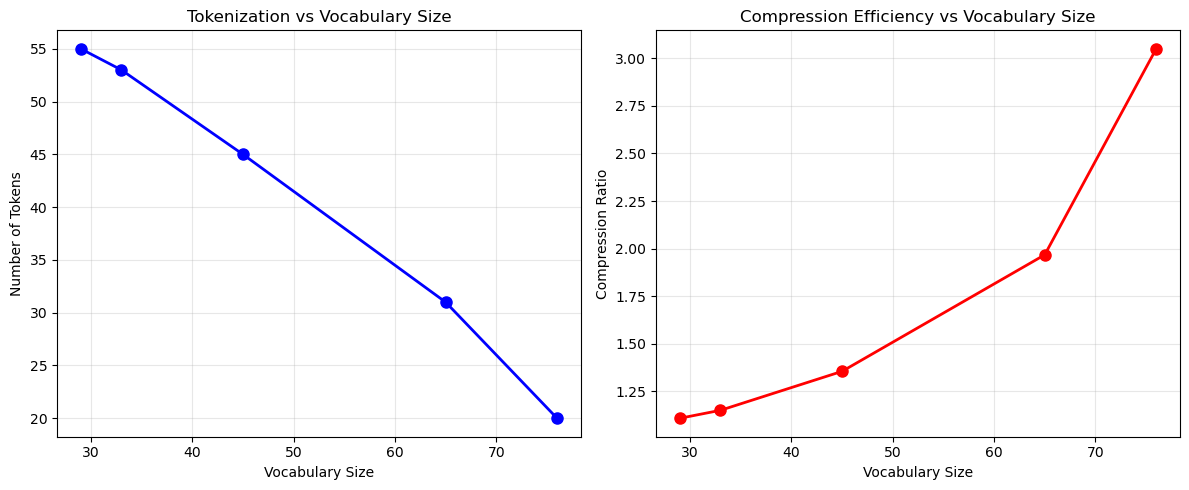

In [14]:
# Let's create a visualization of how BPE vocabulary size affects tokenization
def analyze_vocabulary_sizes():
    """
    Analyze how different vocabulary sizes affect tokenization
    """
    vocab_sizes = [5, 10, 20, 50, 100]
    results = []
    
    test_text = "natural language processing and deep learning neural networks"
    
    for vocab_size in vocab_sizes:
        # Train BPE with different vocabulary sizes
        bpe_test = SimpleBPE()
        merges, vocab = bpe_test.train(larger_corpus.strip(), num_merges=vocab_size)
        
        # Create tokenizer
        tokenizer_test = BPETokenizer()
        tokenizer_test.merges = merges
        tokenizer_test.vocab = vocab
        
        # Tokenize test text
        tokens = tokenizer_test.tokenize(test_text)
        
        results.append({
            'vocab_size': len(vocab),
            'num_tokens': len(tokens),
            'compression_ratio': len(test_text) / len(tokens)
        })
        
        print(f"Vocab size: {len(vocab):3d} | Tokens: {len(tokens):2d} | Compression: {len(test_text) / len(tokens):.2f}x")
    
    return results

results = analyze_vocabulary_sizes()

# Plot the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

vocab_sizes = [r['vocab_size'] for r in results]
token_counts = [r['num_tokens'] for r in results]
compression_ratios = [r['compression_ratio'] for r in results]

ax1.plot(vocab_sizes, token_counts, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Vocabulary Size')
ax1.set_ylabel('Number of Tokens')
ax1.set_title('Tokenization vs Vocabulary Size')
ax1.grid(True, alpha=0.3)

ax2.plot(vocab_sizes, compression_ratios, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Vocabulary Size')
ax2.set_ylabel('Compression Ratio')
ax2.set_title('Compression Efficiency vs Vocabulary Size')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The visualizations above reveal a crucial insight about BPE tokenization: **there's a diminishing returns effect with vocabulary size**.

**Left Plot - Tokenization vs Vocabulary Size:**
- As vocabulary size increases, the number of tokens needed decreases (more efficient encoding)
- The curve flattens quickly - going from 50 to 100 vocabulary items yields minimal improvement
- This means we don't need massive vocabularies to get good compression!

**Right Plot - Compression Efficiency:**
- Compression ratio increases with vocabulary size, but the gains slow down significantly
- Early merges (first 20-50) provide the biggest impact
- Beyond a certain point, adding more merge rules has minimal benefit for compression

**Key Takeaways:**
1. **Sweet Spot**: Most real-world BPE models use vocabularies between 30K-50K tokens
   - Small enough to be manageable and fast
   - Large enough to capture common subwords efficiently
   
2. **Practical Implications**:
   - GPT-2 uses ~50K BPE tokens
   - BERT uses ~30K WordPiece tokens (similar to BPE)
   - These sizes balance compression, semantic meaning, and computational efficiency

3. **The Trade-off**:
   - **Smaller vocab** (5-20 merges): More tokens per sentence, but tiny vocabulary
   - **Medium vocab** (20-50 merges): Good balance - this is what we use!
   - **Larger vocab** (100+ merges): Marginal gains, slower training, risk of overfitting to training data